<a href="https://colab.research.google.com/github/charliemuellerr/mist5400fall2026/blob/main/assignments/mist5400_assignment1_fall2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 1: The DS workflow

**Course:** MIST 5400 Foundations of AI in Business, Fall 2026.    
**Type:** Individual assignment | **Total: 10 points**.   
**Submission:** In Colab, go to *Runtime > Run all* so every output is visible, then *File > Download > Download .ipynb* and upload the file to eLC.     **Notebooks submitted without outputs cannot be graded for the code portions.**.      

---
### Save a copy of this notebook to your Google Drive before making any edits! (File > Save a copy in Drive)
---

## At a glance:

| Part | What it covers |    
| :-- | :-- | :-: |  
| Part 0 | Describe the prediction task precisely |    
| Part A | Descriptive analysis with GenAI assistance |    
| Part B | Build your own model  |  
| Part C | The LLM as the model: zero-shot, then with training data |   
| Part D | Results summary and reflection |      
| **Total** |  | **10** |    

---
## Setup: Load the Dataset

You will use the **Titanic dataset** (predicting passenger survival, a classification task). This is a well-known dataset, so you can focus on the workflow and the prompting experience rather than domain knowledge.

Run the cell below to load the dataset. It is available directly via the `seaborn` library, no file download needed.

The target variable column is `survived` (0 = did not survive, 1 = survived).

In [1]:
import seaborn as sns
import pandas as pd

# Load the Titanic dataset
df = sns.load_dataset('titanic')
df = df.drop(columns=['alive'])

print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (891, 14)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,True


---
## Part 0: Context & Describe the Prediction Task Precisely (1 point)

**About the dataset:** On April 15, 1912, the Titanic sank after hitting an iceberg, and 1,502 of the 2,224 people aboard died. Lifeboat seats were scarce, and survival was not random: some groups of passengers were far more likely to make it than others.

The dataset you loaded above contains records of 891 individual passengers. Each row is one passenger. The columns include whether the passenger survived (`survived`: 0 = no, 1 = yes), along with information known about them before the disaster: ticket class (`pclass`: 1st, 2nd, or 3rd), `sex`, `age`, the number of siblings or spouses aboard (`sibsp`), the number of parents or children aboard (`parch`), the ticket fare paid (`fare`), and the port where they boarded (`embarked`). A few extra columns (`who`, `adult_male`, `deck`, `alone`) are derived from these.

Imagine you are an analyst who has been handed this table and asked: given what we know about a passenger, can we tell how likely they were to survive?

Before touching any code or GenAI tool, describe this ML task the way we practiced in class, by filling in the template below.

**1. The prediction task (0.5 pt):**

> For each **[passenger]**, predict **[target variable]**, given **[a few example features]**.

For each passenger, predict whether they survived (0 = no, 1 = yes), given ticket class, sex, age, number of siblings or spouses aboard, number of parents or children aboard, fare paid, and port of embarkation



**2. Two quick checks (0.25 pt each):**

- Is this supervised or unsupervised learning? How do you know?
- Is this a classification or a regression task? How do you know?

*Your answers:* (For each passenger, predict whether they survived, given their ticket class, sex, age, and fare paid.)

---
## Part A: Descriptive Analysis with GenAI Assistance (1.5 points)

Before building any model, it is important to understand your data. Use your GenAI tool to help you write code that explores the Titanic dataset.

**Your task:**
1. Ask your GenAI tool to help you write Python code to explore this dataset (summary statistics, the distribution of the target variable `survived`, etc.).
2. **Paste and run** the generated code below. Fix any errors if needed.
3. Report **2 to 3 interesting patterns** you found. Be concise, one or two sentences per pattern. At least one pattern should involve the target variable (e.g., which groups survived at higher rates).

> **Full credit:** the exact prompt is recorded (0.5), the code runs with visible outputs including the distribution of `survived` (0.5), and 2 to 3 patterns are reported that match what your outputs actually show, at least one involving survival (0.5).

**Prompt you used:**

> Write Python code to perform descriptive analysis on the Titanic dataset. Include summary statistics, the distribution of the target variable survived, and comparisons of survival rates across important passenger characteristics such as sex, passenger class, and age.

--- Dataset Information ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(4)
memory usage: 73.7+ KB

--- Summary Statistics for Numerical Columns ---
         survived      pclass         age   

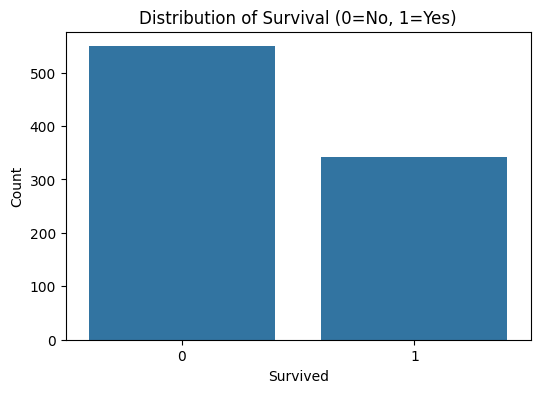


--- Survival Rates by Sex ---
      sex  survived
0  female  0.742038
1    male  0.188908


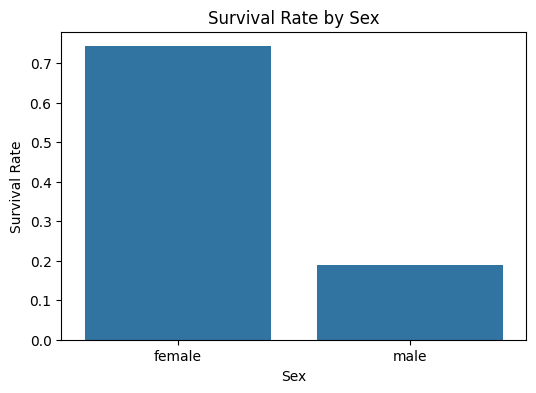


--- Survival Rates by Passenger Class ---
   pclass  survived
0       1  0.629630
1       2  0.472826
2       3  0.242363


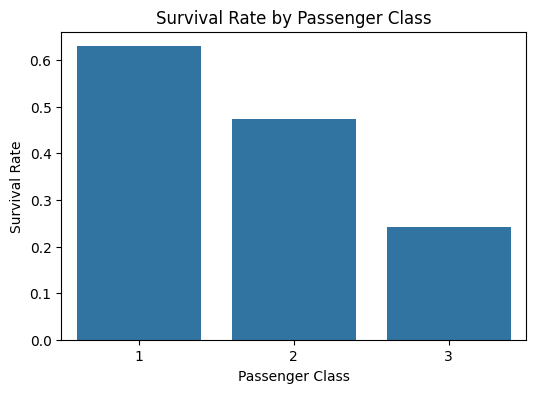


--- Survival Rates by Age Groups ---
  age_group  survived
0      0-10  0.593750
1     11-20  0.382609
2     21-30  0.365217
3     31-40  0.445161
4     41-50  0.383721
5     51-60  0.404762
6     61-70  0.235294
7     71-80  0.200000


/tmp/ipykernel_523/1781887108.py:57: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  survival_by_age_group = df.groupby('age_group')['survived'].mean().reset_index()


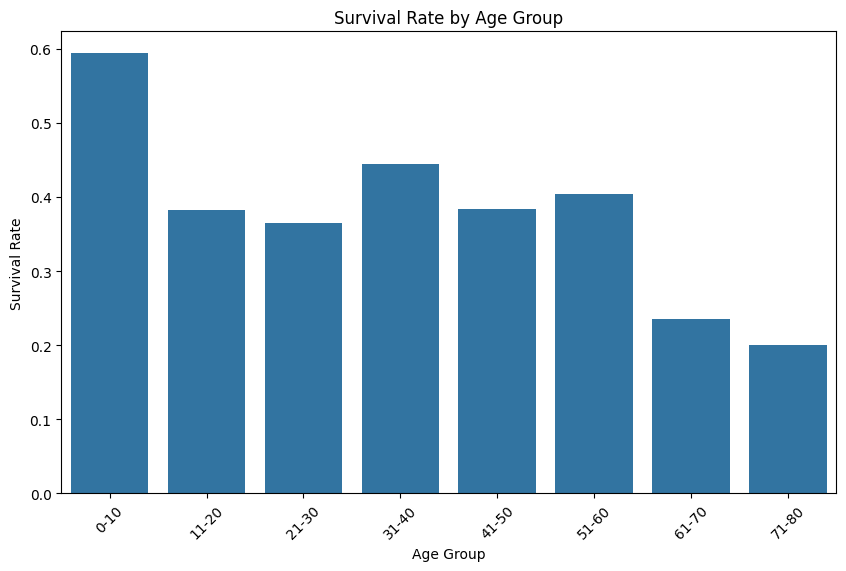

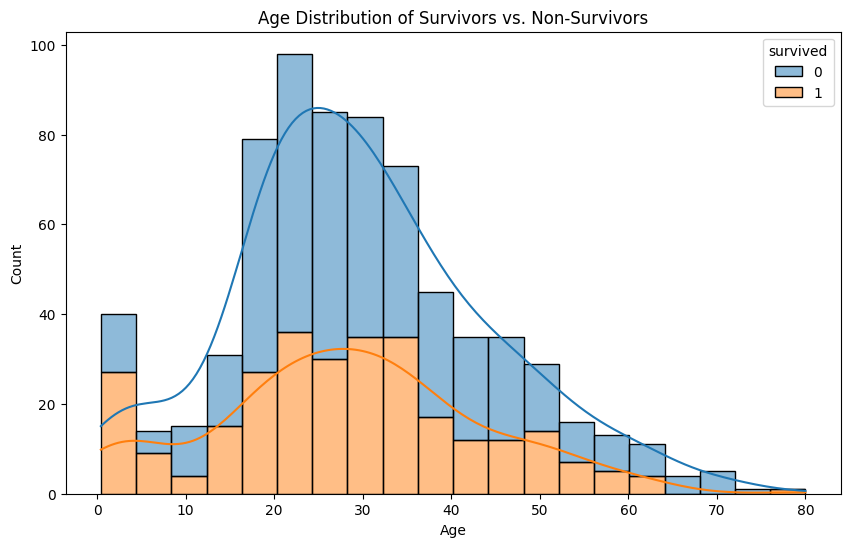

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Assuming 'df' is already loaded from the previous cells.
# If not, you might need to uncomment and run the following lines:
# import seaborn as sns
# df = sns.load_dataset('titanic')
# df = df.drop(columns=['alive'])

print("--- Dataset Information ---")
df.info()
print("\n--- Summary Statistics for Numerical Columns ---")
print(df.describe())
print("\n--- Summary Statistics for Categorical Columns ---")
print(df.describe(include=['object', 'category']))

# Distribution of the target variable 'survived'
print("\n--- Distribution of 'survived' ---")
print(df['survived'].value_counts(normalize=True))

plt.figure(figsize=(6, 4))
sns.countplot(x='survived', data=df)
plt.title('Distribution of Survival (0=No, 1=Yes)')
plt.xlabel('Survived')
plt.ylabel('Count')
plt.show()

# Survival rates by 'sex'
print("\n--- Survival Rates by Sex ---")
survival_by_sex = df.groupby('sex')['survived'].mean().reset_index()
print(survival_by_sex)

plt.figure(figsize=(6, 4))
sns.barplot(x='sex', y='survived', data=survival_by_sex)
plt.title('Survival Rate by Sex')
plt.xlabel('Sex')
plt.ylabel('Survival Rate')
plt.show()

# Survival rates by 'pclass'
print("\n--- Survival Rates by Passenger Class ---")
survival_by_pclass = df.groupby('pclass')['survived'].mean().reset_index()
print(survival_by_pclass)

plt.figure(figsize=(6, 4))
sns.barplot(x='pclass', y='survived', data=survival_by_pclass)
plt.title('Survival Rate by Passenger Class')
plt.xlabel('Passenger Class')
plt.ylabel('Survival Rate')
plt.show()

# Survival rates by 'age'
print("\n--- Survival Rates by Age Groups ---")
# Create age bins for better visualization of survival rates across age
df['age_group'] = pd.cut(df['age'], bins=[0, 10, 20, 30, 40, 50, 60, 70, 80], labels=['0-10', '11-20', '21-30', '31-40', '41-50', '51-60', '61-70', '71-80'])
survival_by_age_group = df.groupby('age_group')['survived'].mean().reset_index()
print(survival_by_age_group)

plt.figure(figsize=(10, 6))
sns.barplot(x='age_group', y='survived', data=survival_by_age_group, order=df['age_group'].cat.categories)
plt.title('Survival Rate by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Survival Rate')
plt.xticks(rotation=45)
plt.show()

# Visualize age distribution for survivors vs non-survivors
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='age', hue='survived', multiple='stack', kde=True)
plt.title('Age Distribution of Survivors vs. Non-Survivors')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()


**Interesting patterns you found:**

1. overall 38.4% of passengers surivived, while 61.6% did not
2. female passengers had a much higher survive rate (74.2% vs 18.9%)
3.Surival rate was strongly realted to passenger class. First class passengers had a stronger survival than first class, and second class had stronger survival than third class.

---
## Part B: Modeling and Evaluation (2 points)

Now build a logistic regression model, following the evaluation workflow from lecture: **split the data, define the model, train it on the training set, predict on the testing set, and evaluate.**

You will use your GenAI tool here too, but with one rule: **one step at a time**. For each step below, write a prompt asking for the Python code for just that step, record your prompt, paste the code into that step's cell, and run it before moving on.

The data preparation is done for you in the next cell. Run it first.



In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

# --- Data preparation (done for you, do not change) ---
model_df = df[['survived', 'pclass', 'sex', 'age', 'fare']].dropna().copy()
model_df['sex'] = (model_df['sex'] == 'female').astype(int)  # 1 = female, 0 = male

X = model_df[['pclass', 'sex', 'age', 'fare']]   # features
y = model_df['survived']                          # target variable

print("Features:", list(X.columns))
print("Number of passengers:", len(model_df))

### Step 1: Split the data (0.25 pt)

Ask your GenAI tool for code that splits `X` and `y` into a training set and a testing set, with **30% of the data for testing** and `random_state=42`. The code should create `X_train`, `X_test`, `y_train`, `y_test`.

**Your prompt:**

> *Paste your exact prompt here*

In [ ]:
# Step 1: Paste and run the GenAI code that splits the data here.

### Step 2: Define and train the model (0.25 pt)

Ask for code that defines a **logistic regression** model and trains it on the training set. The code should create a variable called `model`. (If you hit a warning about iterations not converging, ask your tool to increase `max_iter`.)

**Your prompt:**

> *Paste your exact prompt here*

In [ ]:
# Step 2: Paste and run the GenAI code that defines and trains the model here.

### Step 3: Make predictions (0.25 pt)

Ask for code that uses the trained model to make predictions, creating `y_pred`. Think first, then say it explicitly in your prompt: which set should the model predict on, so that you can see how it does on data it never saw during training?

**Your prompt:**

> *Paste your exact prompt here*

In [ ]:
# Step 3: Paste and run the GenAI code that makes the predictions here.

### Step 4: Evaluate (0.25 pt)

Ask for code that reports the **accuracy** and the **confusion matrix** of your predictions.

**Your prompt:**

> *Paste your exact prompt here*

In [ ]:
# Step 4: Paste and run the GenAI code that evaluates the predictions here.

**Two short questions (0.5 pt each):**

**B1.** Why do we evaluate the model on the testing set instead of the training set? Use the word *overfitting* correctly in your answer.

*Your answer:*

**B2.** In lecture we said training means minimizing a loss function. Which loss function does logistic regression minimize, and why don't we use mean squared error here?

*Your answer:*


---
## Part C: The LLM as the Model (4 points, 2 per task)

You just built a model one step at a time, with GenAI as your **coding assistant**. In this part, the LLM **is the model**: no code is generated, no model is trained. Your code sends passenger data straight to Gemini and asks it to predict survival, exactly the "LLM as the model" evaluation flow from lecture: define the task, ask for predictions on instances with the labels held back, then evaluate against the true labels.

| Task | How you use Gemini | What comes back |
| :-- | :-- | :-- |
| 1 | Send the 10 test passengers, zero-shot | Predictions from the LLM itself |
| 2 | Send the training data first, then ask twice | Predictions from the LLM itself, twice |

You will call **Gemini directly from this Colab notebook with code**, using Colab's built in `google.colab.ai` library. It is free for all Colab users (with monthly usage limits), needs no account setup and no API key, and it means no copy pasting rows into a chat window. It only works inside Google Colab, which is where you are.

**Reproducibility note:** do not change the `random_state` values in the provided cells. They make sure everyone works with the same sampled rows, which keeps grading consistent. One exception to expect: the Gemini cells can give different answers each time they run. That is part of the lesson in Task 2. If you re-run a Gemini cell after recording its predictions, just update your recorded list so it matches the response currently shown.


---
### Task 1: Direct Prediction, Zero-Shot (2 points)

No training examples are given here: Gemini must reason from what it already knows. This is **zero-shot** prompting.

**Step 1.** Run the cell below. It loads Colab's built in Gemini library and builds the test data: 10 passengers with the `survived` column hidden. The true labels stay in the notebook, unseen by Gemini.

In [ ]:
from google.colab import ai   # Colab's built in Gemini access. Free, no API key needed.

# Build the test data: 10 passengers, labels hidden from Gemini
cols = ['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked']
sample = df.sample(10, random_state=42)
true_labels = sample['survived'].values                       # we keep these!
test_text = sample[cols].reset_index(drop=True).to_string()
print(test_text)

**Step 2.** Write your zero-shot prompt in the cell below, between the triple quotes. Your prompt should:

- explain what the data is (Titanic passengers) and what each row represents,
- ask Gemini to predict `survived` as 0 or 1 for **each** passenger, with one line of reasoning per passenger,
- tell Gemini to **end its reply with the 10 predictions as a plain Python list**, e.g. `[0, 1, 0, 1, 1, 0, 0, 1, 0, 1]` (this makes Step 3 easy).

The code then attaches the 10 rows to your prompt and sends everything to Gemini. Run it and read the response.

In [ ]:
# TODO: write your zero-shot prompt between the triple quotes.
my_zero_shot_prompt = """
predict for each row, if this person will survive (1) or not (0)
"""

response_zero_shot = ai.generate_text(my_zero_shot_prompt + "\n\nHere are the 10 passengers:\n" + test_text)
print(response_zero_shot)

**Step 3.** Copy Gemini's 10 predictions into the list below (in the same order as the rows), then run the cell. It computes the accuracy and confusion matrix against the true labels, the same evaluation you did in Part B.

In [ ]:
# Copy Gemini's 10 predictions into this list, in order
gemini_preds_zero_shot = []   # e.g. [0, 1, 1, 0, 1, 0, 0, 1, 1, 0]

from sklearn.metrics import accuracy_score, confusion_matrix
print("True labels: ", list(true_labels))
print("Predictions: ", gemini_preds_zero_shot)
print("Accuracy:", accuracy_score(true_labels, gemini_preds_zero_shot))
print("Confusion matrix:")
print(confusion_matrix(true_labels, gemini_preds_zero_shot))

> **Full credit for Task 1:** your prompt is written in the cell (not left blank) and covers the three requirements above, with Gemini's full response visible (1); the prediction list is filled in to match the response shown, and the evaluation cell runs, showing accuracy and the confusion matrix (1).

---
### Task 2: Give Gemini the Training Data, Then Ask Twice (2 points)

Now repeat the prediction, but first give Gemini **training data: passengers with their known survival outcome**. This is **in-context learning**, the "fake training" idea from lecture: the labeled examples go into the prompt, the model's weights never change, yet the model can pick up the patterns before predicting.

You will also ask **twice with the exact same prompt**, and check whether the answers agree.

**Step 1.** Run the cell below. It builds the training data: 100 passengers WITH the `survived` outcome, excluding the 10 test passengers (no data leakage, same rule as always: judge the model on labels it never saw).

In [ ]:
# Build the training data: 100 passengers WITH the survived outcome.
# The 10 test passengers from Task 1 are excluded. No data leakage!
train_pool = df.drop(sample.index)
train_sample = train_pool.sample(100, random_state=7)
train_text = train_sample[cols + ['survived']].reset_index(drop=True).to_string()
print("Training passengers:", len(train_sample))
print(train_text[:500])  # preview of the first few rows

**Step 2.** Write your prompt in the cell below, between the triple quotes. Your prompt should:

- tell Gemini it is getting training data of Titanic passengers that includes whether each one survived, and that it should learn the patterns from it,
- ask it to then predict `survived` as 0 or 1 for the 10 **new** passengers, with brief reasoning,
- tell it to **end the reply with the 10 predictions as a plain Python list**.

The code attaches the training data and the 10 test rows, and sends it all to Gemini. Run it and read the response.

In [ ]:
# TODO: write your prompt between the triple quotes.
my_training_prompt = """
predict for each row, if this person will survive (1) or not (0)
"""

full_prompt = (my_training_prompt
               + "\n\nTraining data (with the survived outcome):\n" + train_text
               + "\n\nNow predict for these 10 new passengers:\n" + test_text)

response_run1 = ai.generate_text(full_prompt)
print(response_run1)

**Step 3.** Now ask a **second time**. Run the cell below. It sends the **exact same** `full_prompt` again. Do not change anything.

In [ ]:
# Run the EXACT same prompt a second time. Do not change anything.
response_run2 = ai.generate_text(full_prompt)
print(response_run2)

**Step 4.** Copy the predictions from each run into the two lists below, then run the cell. It checks where the two runs agree and evaluates both against the true labels.

In [ ]:
# Copy the 10 predictions from each response into these lists, in order
gemini_preds_run1 = []   # from response_run1
gemini_preds_run2 = []   # from response_run2

agree = sum(int(a == b) for a, b in zip(gemini_preds_run1, gemini_preds_run2))
print(f"The two runs agree on {agree} out of 10 passengers")
print("Run 1 accuracy:", accuracy_score(true_labels, gemini_preds_run1))
print("Run 2 accuracy:", accuracy_score(true_labels, gemini_preds_run2))
print("Zero-shot accuracy (Task 1):", accuracy_score(true_labels, gemini_preds_zero_shot))

**Two short questions (0.25 pt each):**

**C2a.** Compare with Task 1: did giving Gemini the training data change its predictions or its reasoning? In what way?

*Your answer:*

**C2b.** Did the two identical runs give identical predictions? If they differed, where? Why can the exact same prompt produce different outputs from an LLM, and would your logistic regression from Part B ever do that if you ran it twice on the same data?

*Your answer:*


---
## Part D: Comparison and Reflection (1.5 points)

Reflect on what you observed across your own model and the Gemini predictions. There are no right or wrong answers. Full credit comes from being specific: quote your own numbers, describe your own code, refer to your own Gemini outputs. Generic answers that could have been written without doing the assignment receive at most half credit.

### D.1 Results summary table (1 point)

Fill in the table below with your actual results.

| Approach | Who was the model | Accuracy | One thing that surprised you |
| :-- | :-- | :-: | :-- |
| Part B: your logistic regression | A model you trained |  |  |
| Task 1: Zero-shot | Gemini |  |  |
| Task 2 run 1: with training data | Gemini |  |  |
| Task 2 run 2: same prompt again | Gemini |  |  |

*Note: Part B reports accuracy on a test set of hundreds of passengers, while Tasks 1 and 2 use only 10 passengers. Keep that in mind when comparing. We will discuss why this matters more in class.*

> **Full credit:** all cells filled, accuracies match the outputs shown earlier in your notebook.

### D.2 Reflection question (0.5 points)

**What the training data did (Task 1 vs. Task 2):**
Pull together what you saw across the two tasks: how did giving Gemini the training data change things compared to zero-shot, and how consistent was Gemini across the two identical runs? What do these two observations tell you about how LLMs use context and how they generate answers?

*Your answer:*